Parsing dataset file: D:\coding\FYP_Project\Merge\output_dataset\violencehotr\final_violence_train.json...
                  DATASET METRICS SUMMARY                 
Total Images (Records)                  : 425
Total Object Annotations (BBoxes)       : 1940
Total HOI Annotations (Verbs)           : 556
Total Violence Annotations              : 597
Images with Zero Violence Annotations   : 13


C:\Users\Kai\AppData\Local\Temp\ipykernel_40696\2166854974.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=categories, ax=axes[i], palette=sns.color_palette(f"light:{colors[i]}_r", len(counts)))
C:\Users\Kai\AppData\Local\Temp\ipykernel_40696\2166854974.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=categories, ax=axes[i], palette=sns.color_palette(f"light:{colors[i]}_r", len(counts)))
C:\Users\Kai\AppData\Local\Temp\ipykernel_40696\2166854974.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts


[Success] Analysis histograms safely compiled and saved to: dataset_analysis_plots.png


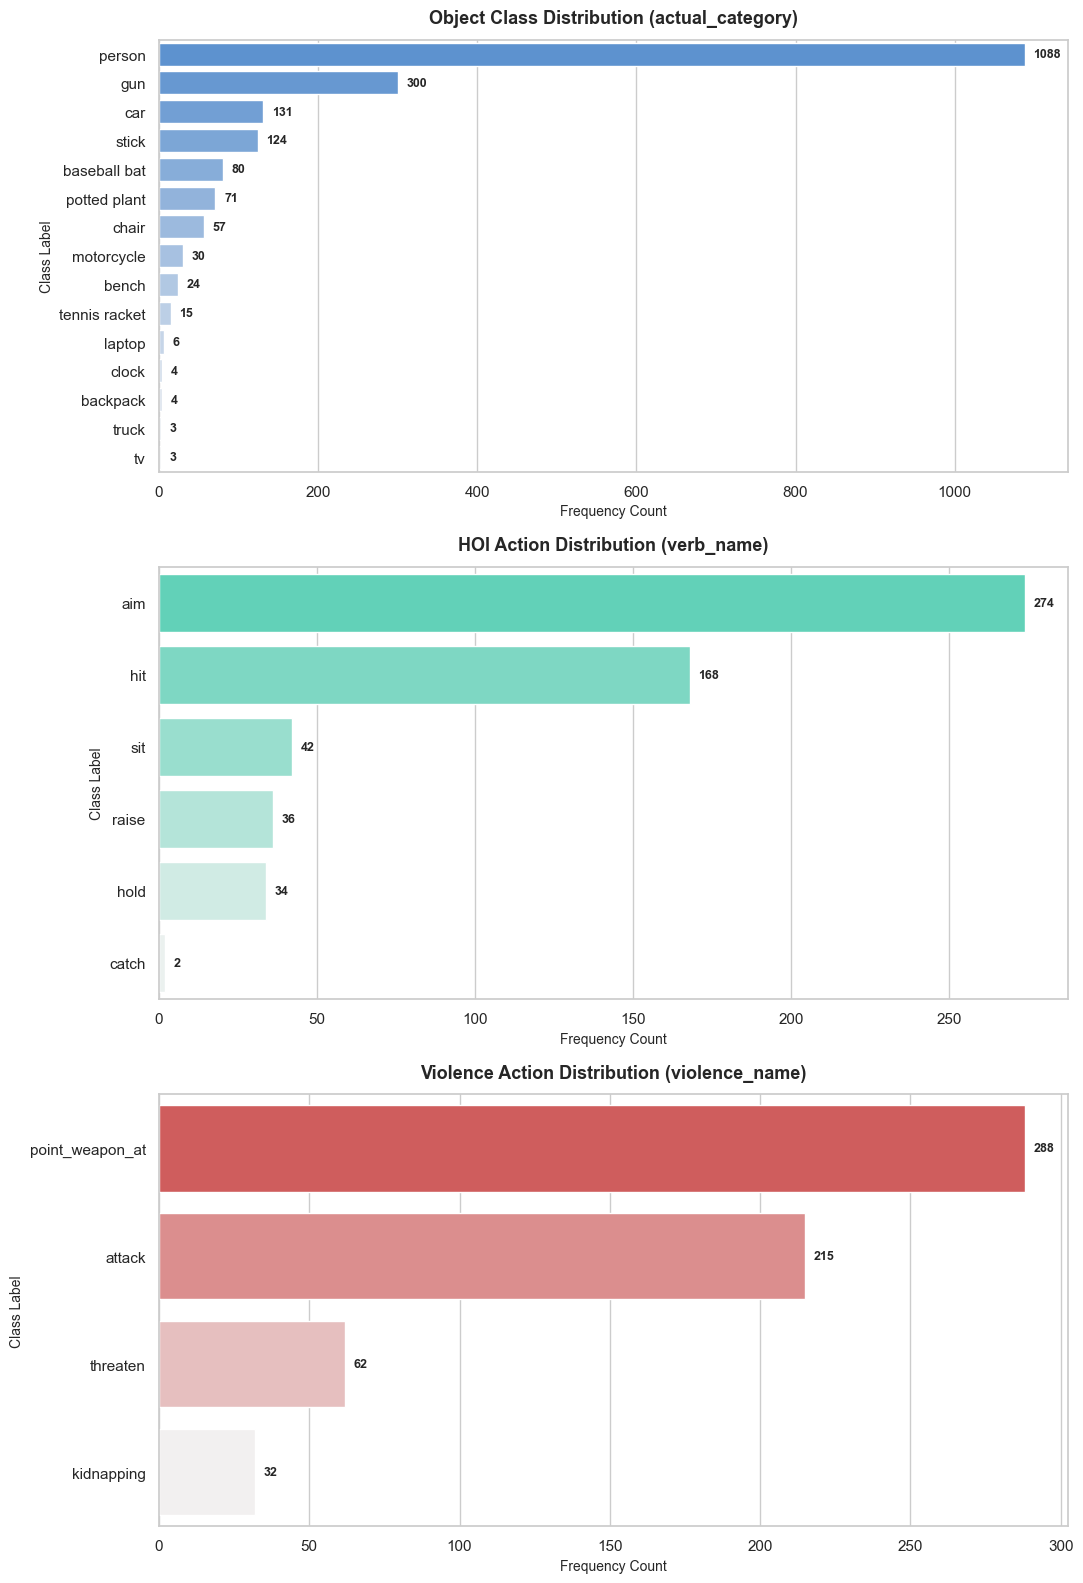

In [ ]:
import json
import os
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# ── CONFIGURATION ───────────────────────────────────────────────────────────
JSON_PATH = r"D:\coding\FYP_Project\Merge\output_dataset\violencehotr\final_violence_train.json"
OUTPUT_PLOT_PATH = "dataset_analysis_plots.png"

def load_json(path: str) -> list:
    with open(path, "r") as f:
        data = json.load(f)
    if isinstance(data, dict):
        for key in ("data", "annotations", "images", "dataset"):
            if key in data:
                return data[key]
        raise ValueError(f"Unexpected dict structure. Keys: {list(data.keys())}")
    return data

def extract_metrics_and_categories(records: list):
    # Initialize Counters & Counters for metrics
    obj_categories = []
    hoi_actions = []
    vio_actions = []
    
    total_images = len(records)
    total_obj_annotations = 0
    total_hoi_annotations = 0
    total_vio_annotations = 0
    empty_vio_records = 0

    for record in records:
        # 1. Object Annotations
        anns = record.get("annotations", [])
        total_obj_annotations += len(anns)
        for ann in anns:
            cat = ann.get("actual_category")
            if cat is not None:
                obj_categories.append(str(cat))

        # 2. HOI Annotations
        hois = record.get("hoi_annotation", [])
        total_hoi_annotations += len(hois)
        for hoi in hois:
            verb = hoi.get("verb_name")
            if verb is not None:
                hoi_actions.append(str(verb))

        # 3. Violence Annotations
        vios = record.get("violence_annotation", [])
        total_vio_annotations += len(vios)
        if not vios:
            empty_vio_records += 1
        for vio in vios:
            vio_name = vio.get("violence_name")
            if vio_name is not None:
                vio_actions.append(str(vio_name))

    # Print Summary Report to Console
    print("=" * 60)
    print("                  DATASET METRICS SUMMARY                 ")
    print("=" * 60)
    print(f"{'Total Images (Records)':<40}: {total_images}")
    print(f"{'Total Object Annotations (BBoxes)':<40}: {total_obj_annotations}")
    print(f"{'Total HOI Annotations (Verbs)':<40}: {total_hoi_annotations}")
    print(f"{'Total Violence Annotations':<40}: {total_vio_annotations}")
    print(f"{'Images with Zero Violence Annotations':<40}: {empty_vio_records}")
    print("=" * 60)

    return {
        "objects": Counter(obj_categories),
        "hoi": Counter(hoi_actions),
        "violence": Counter(vio_actions)
    }

def generate_plots(data_counters: dict, output_path: str):
    # Set styling style for a formal report
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(3, 1, figsize=(11, 16))
    
    titles = [
        "Object Class Distribution (actual_category)",
        "HOI Action Distribution (verb_name)",
        "Violence Action Distribution (violence_name)"
    ]
    keys = ["objects", "hoi", "violence"]
    colors = ["#4A90E2", "#50E3C2", "#E24A4A"] # Professional Blue, Teal, and Alert Red

    for i, key in enumerate(keys):
        counter = data_counters[key]
        if not counter:
            axes[i].text(0.5, 0.5, f"No Data Found for {titles[i]}", 
                         ha='center', va='center', fontsize=14, color='gray')
            axes[i].set_title(titles[i], fontsize=14, fontweight='bold', pad=10)
            continue
            
        # Sort data by frequency descending
        sorted_data = counter.most_common()
        categories = [item[0] for item in sorted_data]
        counts = [item[1] for item in sorted_data]

        # Render horizontal bar charts for clear text readability
        sns.barplot(x=counts, y=categories, ax=axes[i], palette=sns.color_palette(f"light:{colors[i]}_r", len(counts)))
        
        axes[i].set_title(titles[i], fontsize=13, fontweight='bold', pad=12)
        axes[i].set_xlabel("Frequency Count", fontsize=10)
        axes[i].set_ylabel("Class Label", fontsize=10)
        
        # Add value numbers to the end of bars
        for index, value in enumerate(counts):
            axes[i].text(value + (max(counts) * 0.01), index, str(value), 
                         va='center', fontsize=9, fontweight='semibold')

    plt.tight_layout()
    # plt.savefig(output_path, dpi=300)
    print(f"\n[Success] Analysis histograms safely compiled and saved to: {output_path}")

def main():
    if not os.path.exists(JSON_PATH):
        print(f"Error: Could not find dataset JSON file at {JSON_PATH}")
        return

    print(f"Parsing dataset file: {JSON_PATH}...")
    records = load_json(JSON_PATH)
    counters = extract_metrics_and_categories(records)
    generate_plots(counters, OUTPUT_PLOT_PATH)

if __name__ == "__main__":
    main()

Parsing dataset file: D:\coding\FYP_Project\Merge\output_dataset\violencehotr\final_violence_val.json...
                  DATASET METRICS SUMMARY                 
Total Images (Records)                  : 108
Total Object Annotations (BBoxes)       : 533
Total HOI Annotations (Verbs)           : 157
Total Violence Annotations              : 168
Images with Zero Violence Annotations   : 5


C:\Users\Kai\AppData\Local\Temp\ipykernel_40696\1537078239.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=categories, ax=axes[i], palette=sns.color_palette(f"light:{colors[i]}_r", len(counts)))
C:\Users\Kai\AppData\Local\Temp\ipykernel_40696\1537078239.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=categories, ax=axes[i], palette=sns.color_palette(f"light:{colors[i]}_r", len(counts)))
C:\Users\Kai\AppData\Local\Temp\ipykernel_40696\1537078239.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y

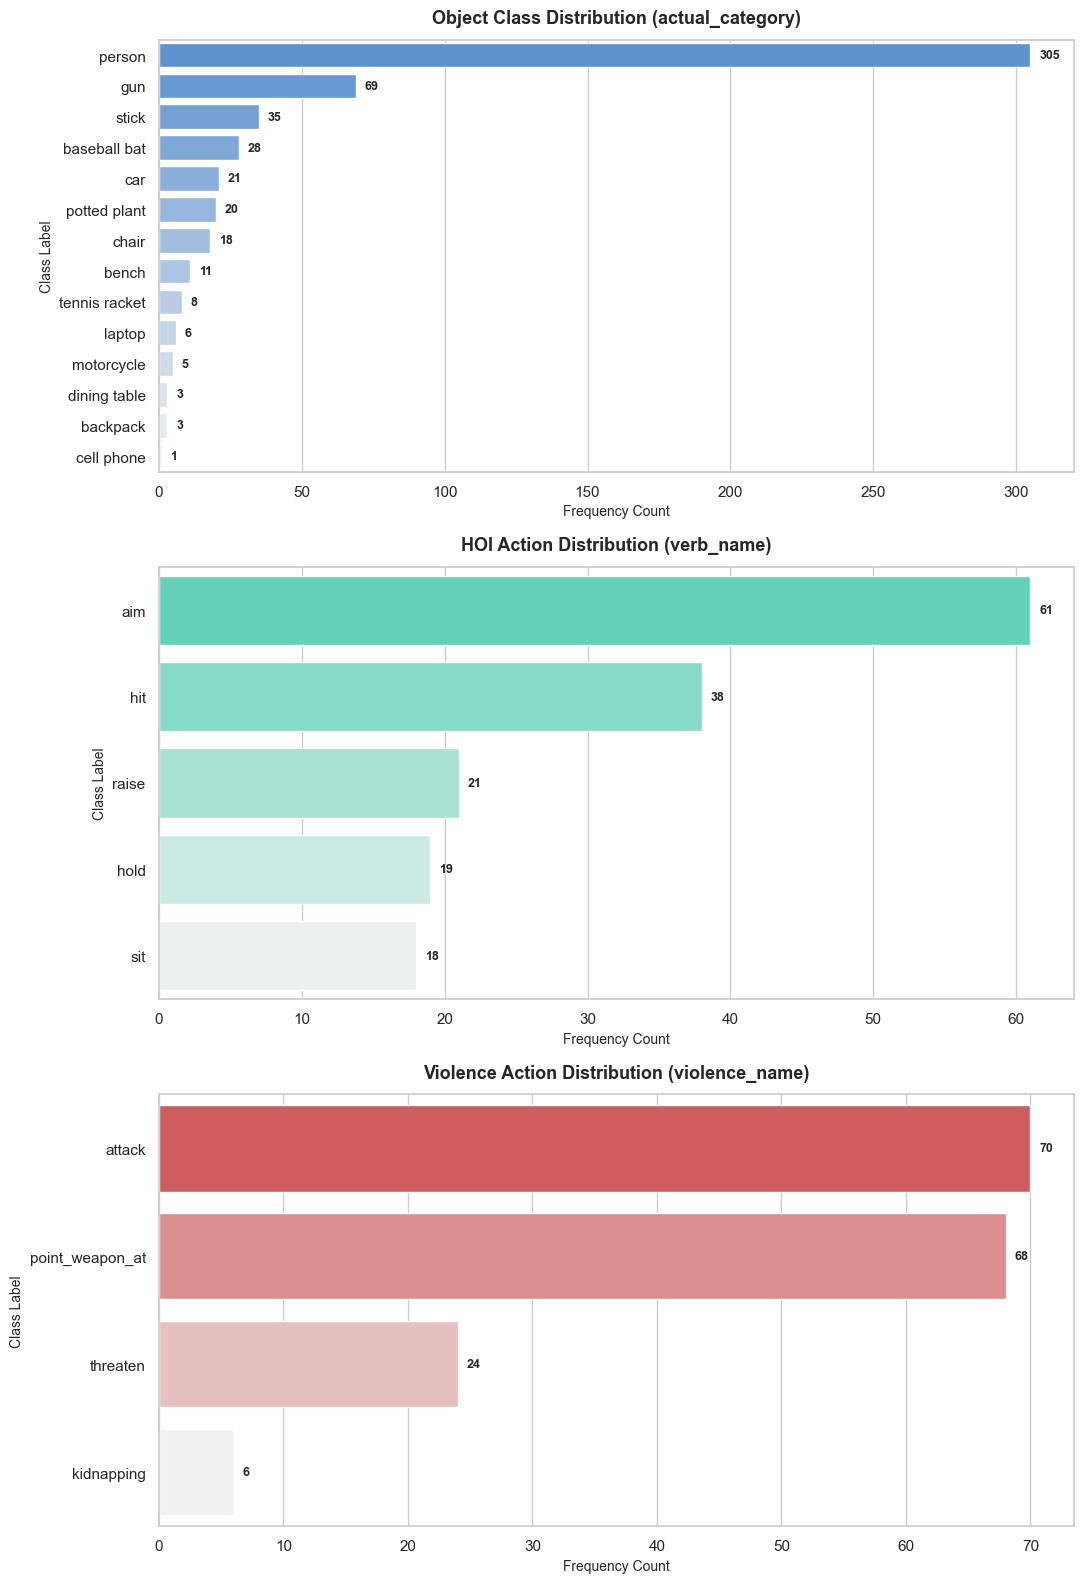

In [ ]:
# ── CONFIGURATION ───────────────────────────────────────────────────────────
JSON_PATH = r"D:\coding\FYP_Project\Merge\output_dataset\violencehotr\final_violence_val.json"

def load_json(path: str) -> list:
    with open(path, "r") as f:
        data = json.load(f)
    if isinstance(data, dict):
        for key in ("data", "annotations", "images", "dataset"):
            if key in data:
                return data[key]
        raise ValueError(f"Unexpected dict structure. Keys: {list(data.keys())}")
    return data

def extract_metrics_and_categories(records: list):
    # Initialize Counters & Counters for metrics
    obj_categories = []
    hoi_actions = []
    vio_actions = []
    
    total_images = len(records)
    total_obj_annotations = 0
    total_hoi_annotations = 0
    total_vio_annotations = 0
    empty_vio_records = 0

    for record in records:
        # 1. Object Annotations
        anns = record.get("annotations", [])
        total_obj_annotations += len(anns)
        for ann in anns:
            cat = ann.get("actual_category")
            if cat is not None:
                obj_categories.append(str(cat))

        # 2. HOI Annotations
        hois = record.get("hoi_annotation", [])
        total_hoi_annotations += len(hois)
        for hoi in hois:
            verb = hoi.get("verb_name")
            if verb is not None:
                hoi_actions.append(str(verb))

        # 3. Violence Annotations
        vios = record.get("violence_annotation", [])
        total_vio_annotations += len(vios)
        if not vios:
            empty_vio_records += 1
        for vio in vios:
            vio_name = vio.get("violence_name")
            if vio_name is not None:
                vio_actions.append(str(vio_name))

    # Print Summary Report to Console
    print("=" * 60)
    print("                  DATASET METRICS SUMMARY                 ")
    print("=" * 60)
    print(f"{'Total Images (Records)':<40}: {total_images}")
    print(f"{'Total Object Annotations (BBoxes)':<40}: {total_obj_annotations}")
    print(f"{'Total HOI Annotations (Verbs)':<40}: {total_hoi_annotations}")
    print(f"{'Total Violence Annotations':<40}: {total_vio_annotations}")
    print(f"{'Images with Zero Violence Annotations':<40}: {empty_vio_records}")
    print("=" * 60)

    return {
        "objects": Counter(obj_categories),
        "hoi": Counter(hoi_actions),
        "violence": Counter(vio_actions)
    }

def generate_plots(data_counters: dict):
    # Set styling style for a formal report
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(3, 1, figsize=(11, 16))
    
    titles = [
        "Object Class Distribution (actual_category)",
        "HOI Action Distribution (verb_name)",
        "Violence Action Distribution (violence_name)"
    ]
    keys = ["objects", "hoi", "violence"]
    colors = ["#4A90E2", "#50E3C2", "#E24A4A"] # Professional Blue, Teal, and Alert Red

    for i, key in enumerate(keys):
        counter = data_counters[key]
        if not counter:
            axes[i].text(0.5, 0.5, f"No Data Found for {titles[i]}", 
                         ha='center', va='center', fontsize=14, color='gray')
            axes[i].set_title(titles[i], fontsize=14, fontweight='bold', pad=10)
            continue
            
        # Sort data by frequency descending
        sorted_data = counter.most_common()
        categories = [item[0] for item in sorted_data]
        counts = [item[1] for item in sorted_data]

        # Render horizontal bar charts for clear text readability
        sns.barplot(x=counts, y=categories, ax=axes[i], palette=sns.color_palette(f"light:{colors[i]}_r", len(counts)))
        
        axes[i].set_title(titles[i], fontsize=13, fontweight='bold', pad=12)
        axes[i].set_xlabel("Frequency Count", fontsize=10)
        axes[i].set_ylabel("Class Label", fontsize=10)
        
        # Add value numbers to the end of bars
        for index, value in enumerate(counts):
            axes[i].text(value + (max(counts) * 0.01), index, str(value), 
                         va='center', fontsize=9, fontweight='semibold')

    plt.tight_layout()

def main():
    if not os.path.exists(JSON_PATH):
        print(f"Error: Could not find dataset JSON file at {JSON_PATH}")
        return

    print(f"Parsing dataset file: {JSON_PATH}...")
    records = load_json(JSON_PATH)
    counters = extract_metrics_and_categories(records)
    generate_plots(counters)

if __name__ == "__main__":
    main()